In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import mu_0, epsilon_0
from scipy.special import ellipk

In [2]:
def calc_cpw_param_set(
    center_width: float, gap_width: float, substrate_r: float, metal_thickness: float
):
    a = center_width / 2
    b = center_width / 2 + gap_width
    d = metal_thickness / (2 * np.pi)

    u1 = (
        a
        + d / 2
        + 3 / 2 * np.log(2) * d
        - d / 2 * np.log(d / a)
        + d / 2 * np.log((b - a) / (a + b))
    )
    u2 = (
        b
        - d / 2
        - 3 / 2 * np.log(2) * d
        + d / 2 * np.log(d / a)
        + d / 2 * np.log((b - a) / (a + b))
    )
    k1 = u1 / u2
    k2 = np.sqrt(1 - k1**2)
    c = 2 * epsilon_0 * ellipk(k1) / ellipk(k2) * (1 + substrate_r)

    d = d/2
    u1 = a+d/2+3/2*np.log(2)*d-d/2*np.log(d/a)+d/2*np.log((b-a)/(a+b))
    u2 = b-d/2-3/2*np.log(2)*d+d/2*np.log(d/a)+d/2*np.log((b-a)/(a+b))
    k1 = u1/u2
    k2 = np.sqrt(1-k1**2)
    l = mu_0/4*ellipk(k2)/ellipk(k1)

    lambda_eff = 50e-9  # m, effective field penetration depth
    k = a/b
    g_ctr = 1/(4*a*ellipk(k)**2*(1-k)**2) * \
        (np.pi+np.log(4*np.pi*a/metal_thickness)-k*np.log((1+k)/(1-k)))
    g_gnd = 1/(4*a*ellipk(k)**2*(1-k)**2) * \
        (np.pi+np.log(4*np.pi*b/metal_thickness)-k*np.log((1+k)/(1-k)))
    g = g_ctr+g_gnd
    l_ki = g*mu_0*lambda_eff
    l_tot = l+l_ki

    return {'inductance': l_tot, 'capacitance': c}


def calc_target_length(target_frequency: float, cpw_param_set: dict):
    return 1e6*3 / (4 * target_frequency * np.sqrt(cpw_param_set['inductance'] * cpw_param_set['capacitance']))

In [3]:
def Z_coupling(Cc: float, omega: float):
    Z_cc = 1 / (1j * omega * Cc)
    return Z_cc 

def Z_open(Z0: float, length: float, beta: float):
    return -1j * Z0 / np.tan(beta * length)


def ABCD_component(Z: complex, Ad: bool = False):
    if Ad:
        return np.array([[1, 0], [1/Z, 1]])
    else:
        return np.array([[1, Z], [0, 1]])

def ABCD_line(Z0: float, length: float, beta: float):
    A = np.cos(beta * length)
    B = 1j * Z0 * np.sin(beta * length)
    C = 1j * np.sin(beta * length) / Z0
    D = np.cos(beta * length)
    return np.array([[A, B], [C, D]])

def ABCD_to_Y(ABCD: np.ndarray):
    A, B, C, D = ABCD.flatten()
    Y11 = D / B
    Y12 = (B * C - A * D) / B
    Y21 = -1 / B
    Y22 = A / B
    return np.array([[Y11, Y12], [Y21, Y22]])

def Y_to_S21(Y: np.ndarray, Z0: float):
    Y0 = 1 / Z0
    Y11, Y12, Y21, Y22 = Y.flatten()
    deltaY = (Y11 + Y0) * (Y22 + Y0) - Y12 * Y21
    S21 = (-2 * Y21 * Y0) / deltaY
    return S21


def Y_to_ABCD(Y):
    Y11, Y12, Y21, Y22 = Y.flatten()
    A = -Y22 / Y21
    B = -1 / Y21
    C = (Y12 * Y21 - Y11 * Y22) / Y21
    D = -Y11 / Y21
    return np.array([[A, B], [C, D]])


def ABCD_to_S21_Norm(ABCD, Z0):

    A,B,C,D = ABCD.flatten()
    return 2/(A + B/Z0 + C*Z0 + D)

def ABCD_to_S21(ABCD, Z1, Z2=None):
    """Generalized S21. If Z2 not given, assumes Z1=Z2 (matched)."""
    if Z2 is None:
        Z2 = Z1
    A, B, C, D = ABCD.flatten()
    delta = A * Z2 + B + C * Z1 * Z2 + D * Z1
    #denom = ((B + C * Z1 * Z2) + (A * Z2 + D * Z2))
    #delta = A + (B/Z2) + C*Z1 + (Z1/Z2)*D
    return 2 * np.sqrt(Z1 * Z2) / delta

In [4]:
h = 6.626e-34
hbar = h/(2*np.pi)
phi_0 = 2.067e-15
E_j0 = 61.56e9 * h
E_c = 177.717e6 * h
d = 0.17

Z_0 = 50
C_c = 8.17e-15
C_T = 100.53e-15
L_T = 10e-9
N = 1000
w_r = 5.5e9*2*np.pi
Z_1 = 10
Z_2 = 10



resonator_widths = [7, 10, 7]

res_cpw_param_set = calc_cpw_param_set(
    center_width= resonator_widths[1]*1e-6, 
    gap_width=resonator_widths[0]*1e-6, 
    substrate_r=11.6, 
    metal_thickness=200e-9
)

l = calc_target_length(5.5e9, res_cpw_param_set)
l_f = l/1e6

l1 = l_f/4
l2 = (2*l_f)/3
l3 = l_f/12
l4 = (7*l_f)/12
l5 = l_f/6
l6 = l_f/4

In [63]:
phi_q1_values = np.linspace(0.382, 0.392, N)*phi_0#(0.578, 0.58, N) * phi_0#(-0.425, -0.415, N) * phi_0 (0.574, 0.584, N)*phi_0
phi_q2_values = np.linspace(0.382, 0.392, N)*phi_0#(-0.422, -0.420, N) * phi_0#(0.57, 0.59, N) * phi_0 (-0.426, -0.416, N)*phi_0
S_21_vals = np.zeros((N,N), dtype=complex)
f_q1_vals = np.zeros(N)
f_q2_vals = np.zeros(N)

Z_open_1 = Z_open(Z_0, l3, w_r*np.sqrt(res_cpw_param_set['inductance'] * res_cpw_param_set['capacitance']))
ABCD_open_1 = ABCD_component(Z_open_1, Ad=True)
Z_open_2 = Z_open(Z_0, l4, w_r*np.sqrt(res_cpw_param_set['inductance'] * res_cpw_param_set['capacitance']))
ABCD_open_2 = ABCD_component(Z_open_2, Ad=True)
Z_cc = Z_coupling(C_c, w_r)



Z_l1 = ABCD_line(Z_0, l1, w_r*np.sqrt(res_cpw_param_set['inductance'] * res_cpw_param_set['capacitance']))
Z_l2 = ABCD_line(Z_0, l2, w_r*np.sqrt(res_cpw_param_set['inductance'] * res_cpw_param_set['capacitance']))
Z_l5 = ABCD_line(Z_0, l5, w_r*np.sqrt(res_cpw_param_set['inductance'] * res_cpw_param_set['capacitance']))
Z_l6 = ABCD_line(Z_0, l6, w_r*np.sqrt(res_cpw_param_set['inductance'] * res_cpw_param_set['capacitance']))


for i1, phi_q1 in enumerate(phi_q1_values):
    E_j1 = E_j0 * np.sqrt(np.cos(np.pi * phi_q1 / phi_0)**2 
                     + d**2 * np.sin(np.pi * phi_q1 / phi_0)**2)
    f_q1 = (np.sqrt(8*E_j1*E_c)-E_c)/h
    f_q1_vals[i1] = f_q1
    omega_q1 = 2 * np.pi * f_q1
    #Z_qc = 1/(1j*omega_q1*C_T)
    #Z_ql = 1j*omega_q1*L_T
    #Z_qubit_1 = (1/Z_qc + 1/Z_ql)**(-1)  #1 / ((1j * w_r * C_T * (1 - (omega_q1 / w_r)**2) + 1e-10))
    Z_qubit_1 = 1 / (1j * w_r * C_T * (1 - (omega_q1 / w_r)**2))
    Z1 = Z_qubit_1 + 2*Z_cc
    ABCD_qubit_1 = ABCD_component(Z1, Ad=False)
    Y_inner_1 = ABCD_to_Y(ABCD_qubit_1)
    for i2, phi_q2 in enumerate(phi_q2_values):
        E_j2 = E_j0 * np.sqrt(np.cos(np.pi * phi_q2 / phi_0)**2 
                         + d**2 * np.sin(np.pi * phi_q2 / phi_0)**2)
        f_q2 = (np.sqrt(8*E_j2*E_c)-E_c)/h
        omega_q2 = 2 * np.pi * f_q2
        #Z_qubit_2 = 1 / ((1j * w_r * C_T * (1 - (omega_q2 / w_r)**2) + 1e-10))
        #Z_qc_2 = 1/(1j*omega_q2*C_T)
        #Z_ql_2 = 1j*omega_q2*L_T
        Z_qubit_2 = 1 / (1j * w_r * C_T * (1 - (omega_q2 / w_r)**2))
        f_q2_vals[i2] = f_q2
        Z2 = Z_qubit_2 + 2*Z_cc
        ABCD_qubit_2 = ABCD_component(Z2, Ad=False)
        Y_inner_2 = ABCD_to_Y(Z_l2 @ ABCD_open_1 @ ABCD_qubit_2 @ ABCD_open_2 @ Z_l5)
        Y_inner = Y_inner_1 + Y_inner_2
        ABCD_inner = Y_to_ABCD(Y_inner)
        ABCD_total = Z_l1 @ ABCD_inner @ Z_l6
        S_21_vals[i1, i2] = ABCD_to_S21(ABCD_total, Z_1, Z_2)

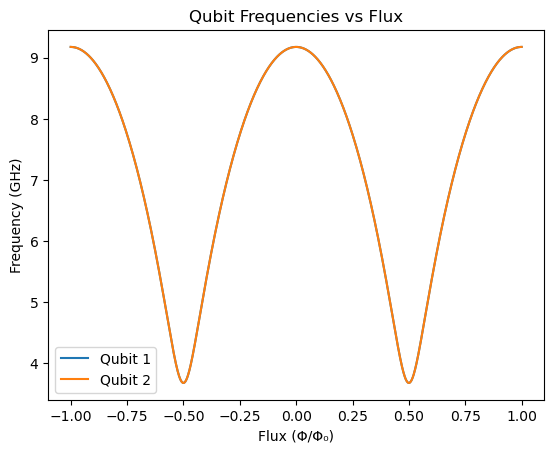

In [12]:
# Check to see whether qubits cross the resonator frequency. Note; it does

plt.plot(phi_q1_values/phi_0, f_q1_vals/1e9, label='Qubit 1')
plt.plot(phi_q2_values/phi_0, f_q2_vals/1e9, label='Qubit 2')
plt.xlabel('Flux (Φ/Φ₀)')
plt.ylabel('Frequency (GHz)')
plt.title('Qubit Frequencies vs Flux')
plt.legend()
plt.show()

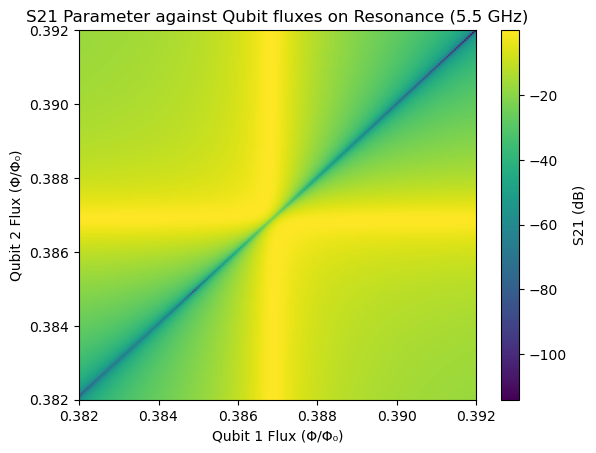

In [64]:
plt.figure()
plt.imshow(
    20 * np.log10(np.abs(S_21_vals)),
    extent=(phi_q2_values[0]/phi_0, phi_q2_values[-1]/phi_0, phi_q1_values[0]/phi_0, phi_q1_values[-1]/phi_0),
    origin='lower',
    aspect='auto',
    cmap='viridis'
)
plt.colorbar(label='S21 (dB)')
plt.xlabel('Qubit 1 Flux (Φ/Φ₀)')
plt.ylabel('Qubit 2 Flux (Φ/Φ₀)')
plt.title('S21 Parameter against Qubit fluxes on Resonance (5.5 GHz)')
plt.show()

In [5]:
def compute_S21_at_freq(f, omega_q1, omega_q2, cpw_params, params):

    w = 2 * np.pi * f
    beta = w * np.sqrt(cpw_params['inductance'] * cpw_params['capacitance'])

    
    Z_o1   = Z_open(params['Z_0'], params['l3'], beta)
    Z_o2   = Z_open(params['Z_0'], params['l4'], beta)
    Z_cc   = 1 / (1j * w * params['C_c'])
    Ml1    = ABCD_line(params['Z_0'], params['l1'], beta)
    Ml2    = ABCD_line(params['Z_0'], params['l2'], beta)
    Ml5    = ABCD_line(params['Z_0'], params['l5'], beta)
    Ml6    = ABCD_line(params['Z_0'], params['l6'], beta)

    # Qubit impedances at probe frequency w, with their own resonant frequencies
    #gamma  = 2 * np.pi * 1e6   # regularization linewidth
    Z_q1   = 1 / (1j * w * params['C_T'] * (1 - (omega_q1/w)**2))
    Z_q2   = 1 / (1j * w * params['C_T'] * (1 - (omega_q2/w)**2))

    Z_bridge_1 = Z_q1 + 2 * Z_cc
    Z_bridge_2 = Z_q2 + 2 * Z_cc

    Y1 = ABCD_to_Y(ABCD_component(Z_bridge_1, Ad=False))
    Y2 = ABCD_to_Y(Ml2 
                   @ ABCD_component(Z_o1, Ad=True) 
                   @ ABCD_component(Z_bridge_2, Ad=False) 
                   @ ABCD_component(Z_o2, Ad=True) 
                   @ Ml5)

    ABCD_inner = Y_to_ABCD(Y1 + Y2)
    ABCD_total = Ml1 @ ABCD_inner @ Ml6
    return ABCD_to_S21(ABCD_total, params['Z_1'], params['Z_2'])

In [6]:
from scipy.constants import k as k_B

def bose(f, T):
    x = h * f / (k_B * T)
    return 1.0 / (np.expm1(x))  

def heat_integrand(f, omega_q1, omega_q2, T1, T2, cpw_params, params):
    S21 = compute_S21_at_freq(f, omega_q1, omega_q2, cpw_params, params)
    tau = np.abs(S21)**2                         
    return h * f * tau * (bose(f, T1) - bose(f, T2))

In [22]:
from scipy.integrate import quad


T1 = 350e-3   
T2 = 50e-3  
N = 500

params = dict(Z_0=Z_0, Z_1=Z_1, Z_2=Z_2, C_c=C_c, C_T=C_T, l1=l1, l2=l2,
              l3=l3, l4=l4, l5=l5, l6=l6)

phi_q1_values = np.linspace(-1, 1, N)*phi_0#(0.578, 0.58, N) * phi_0#(-0.425, -0.415, N) * phi_0 (0.574, 0.584, N)*phi_0
phi_q2_values = np.linspace(-1, 1, N)*phi_0

f_max = 9e9  
f_min = 3e9                            

P_net_vals = np.zeros((N, N))

for i1, phi_q1 in enumerate(phi_q1_values):
    E_j1 = E_j0 * np.sqrt(np.cos(np.pi*phi_q1/phi_0)**2
                         + d**2 * np.sin(np.pi*phi_q1/phi_0)**2)
    f_q1      = (np.sqrt(8*E_j1*E_c) - E_c) / h
    omega_q1  = 2 * np.pi * f_q1

    for i2, phi_q2 in enumerate(phi_q2_values):
        E_j2 = E_j0 * np.sqrt(np.cos(np.pi*phi_q2/phi_0)**2
                             + d**2 * np.sin(np.pi*phi_q2/phi_0)**2)
        f_q2      = (np.sqrt(8*E_j2*E_c) - E_c) / h
        omega_q2  = 2 * np.pi * f_q2

        P_net_vals[i1, i2], _ = quad(
            heat_integrand,
            f_min, f_max,
            args=(omega_q1, omega_q2, T1, T2, res_cpw_param_set, params),
            limit=2000,        
            epsrel=1e-4
        )

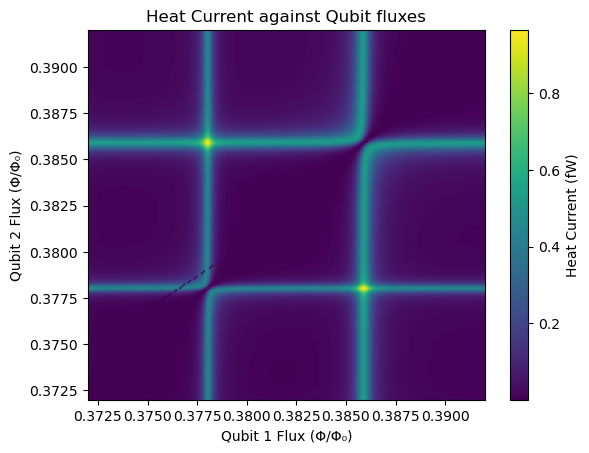

In [18]:
plt.figure()
plt.imshow(
    P_net_vals/1e-15,
    extent=(phi_q2_values[0]/phi_0, phi_q2_values[-1]/phi_0, phi_q1_values[0]/phi_0, phi_q1_values[-1]/phi_0),
    origin='lower',
    aspect='auto',
    cmap='viridis'
)
plt.colorbar(label='Heat Current (fW)')
plt.xlabel('Qubit 1 Flux (Φ/Φ₀)')
plt.ylabel('Qubit 2 Flux (Φ/Φ₀)')
plt.title('Heat Current against Qubit fluxes')
plt.show()

In [23]:
%matplotlib QtAgg

In [24]:
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(
    P_net_vals/1e-15,
    extent=(phi_q2_values[0]/phi_0, phi_q2_values[-1]/phi_0, phi_q1_values[0]/phi_0, phi_q1_values[-1]/phi_0),
    origin='lower',
    aspect='auto',
    cmap='viridis'
)
plt.colorbar(label='Heat Current (fW)')
plt.xlabel('Qubit 1 Flux (Φ/Φ₀)')
plt.ylabel('Qubit 2 Flux (Φ/Φ₀)')
plt.title('Heat Current against Qubit fluxes')
plt.show()
plt.ion()